# Interpolacja trygonometryczna

Interpolacja trygonometryczna zakłada, że funkcja przybiorą postać szeregu Fouriera:

$$y = \frac{A_0}{2} + \sum_{k=1}^{N-1}\big[A_k \cos(kx) + B_k \sin(kx)\big]$$

Bazowe funkcje: $a_0=1$, $a_k=\cos(kx)$, $b_k=\sin(kx)$ dla $k=1,\dots,N-1$. Współczynniki wyznaczamy metodą najmniejszych kwadratów, rozwiązując układ postaci $Fc=y$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def fourier_series_fit(x, y, n_terms):
    """Dopasowanie szeregu Fouriera metodą najmniejszych kwadratów.

    Na podstawie: Matt Tearle (2021), "Simple real Fourier series
    approximation" (funkcje MATLAB `Fseries`/`Fseriesval`),
    MATLAB Central File Exchange.
    """
    n = len(x)
    F = np.zeros((n, 2*n_terms - 1))
    F[:, 0] = 1  # A_0 term
    for k in range(1, n_terms):
        F[:, 2*k - 1] = np.sin(k*x)
        F[:, 2*k] = np.cos(k*x)
    coeffs, _, _, _ = np.linalg.lstsq(F, y, rcond=None)
    a_out = np.zeros(n_terms)
    b_out = np.zeros(n_terms)
    a_out[0] = coeffs[0]
    for k in range(1, n_terms):
        a_out[k] = coeffs[2*k]
        b_out[k] = coeffs[2*k - 1]
    return a_out, b_out

def fourier_series_eval(a, b, x):
    """Ewaluacja szeregu Fouriera.

    Na podstawie: Matt Tearle (2021), "Simple real Fourier series
    approximation" (funkcje MATLAB `Fseries`/`Fseriesval`),
    MATLAB Central File Exchange.
    """
    result = a[0]
    for k in range(1, len(a)):
        result += a[k]*np.cos(k*x) + b[k]*np.sin(k*x)
    return result

## Przykład:Interpolacja $\sin(4x)$ z 11 węzłów

In [2]:
f = lambda x: np.sin(4*x)
noOfPoints = 11
xw = np.linspace(-np.pi, np.pi, noOfPoints)
yw = f(xw)
# Liczba wyrazów szeregu (n_terms) musi dawać dokładnie tyle niewiadomych
# (2*n_terms - 1: wyraz stały + pary sin/cos) ile mamy równań (węzłów),
# inaczej układ jest niedookreślony (za mało równań) lub przeokreślony.
a, b = fourier_series_fit(xw, yw, (noOfPoints + 1) // 2)

for i in range(len(a)):
    print(f'Współczynnik a{i} = {a[i]:.2e}')
for i in range(1, len(b)):
    print(f'Współczynnik b{i} = {b[i]:.2e}')

Współczynnik a0 = 6.29e-18
Współczynnik a1 = -1.10e-16
Współczynnik a2 = -2.11e-17
Współczynnik a3 = 3.49e-17
Współczynnik a4 = -2.71e-16
Współczynnik a5 = -1.47e-16
Współczynnik b1 = -7.33e-17
Współczynnik b2 = -5.55e-17
Współczynnik b3 = -8.33e-17
Współczynnik b4 = 1.00e+00
Współczynnik b5 = 5.91e-16


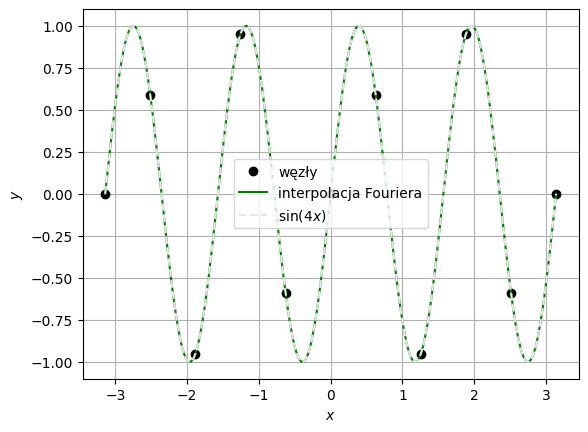

In [3]:
xfine = np.linspace(-np.pi, np.pi, 400)
yfine = fourier_series_eval(a, b, xfine)
plt.plot(xw, yw, 'ko')
plt.plot(xfine, yfine, 'g-')
plt.plot(xfine, f(xfine), '--', color=[0.9, 0.9, 0.9])
plt.grid(True)
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.legend(['węzły', 'interpolacja Fouriera', '$\\sin(4x)$'])
plt.show()

## Ćwiczenie 1a — Porównanie z `scipy`

Użyj `scipy.fftpack` do obliczenia interpolacji fourierowskiej i porównaj wyniki z własną implementacją.

Maksymalna różnica (nasza implementacja vs. scipy.signal.resample): 3.164135620181696e-15


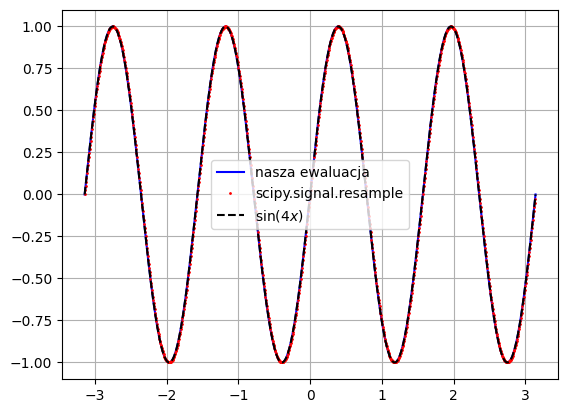

In [4]:
from scipy.fftpack import fft, ifft
from scipy.signal import resample

# Równoważne z interpft w MATLAB
xfine2 = np.linspace(-np.pi, np.pi, 1000)
yinterp = np.zeros(len(xfine2))
for j, xpt in enumerate(xfine2):
    yinterp[j] = fourier_series_eval(a, b, xpt)

# Prawdziwe porównanie z scipy: scipy.signal.resample robi dokładnie to, co
# MATLAB-owe interpft -- dopełnia widmo FFT zerami i wykonuje IFFT, dając
# interpolację trygonometryczną na gęstszej siatce równoodległej. Zakłada
# PRAWDZIWĄ okresowość próbek (ostatnia próbka NIE może być powtórzeniem
# pierwszej), a nasza siatka xw=linspace(-pi,pi,11) jest domknięta
# (xw[-1]=pi pokrywa się z xw[0]=-pi z uwagi na okresowość 2*pi) -- dokładnie
# ta sama konwencja "ostatnia próbka = pierwsza, po cichu pomijana", co w
# Zad 6 sprawdzianu 2. Do resample przekazujemy więc tylko 10 niezależnych
# próbek (bez powtórzonego punktu końcowego).
yw_periodic = yw[:-1]
yinterp_scipy = resample(yw_periodic, len(xfine2))
xfine2_periodic = np.linspace(-np.pi, np.pi, len(xfine2), endpoint=False)
yinterp_own_periodic = fourier_series_eval(a, b, xfine2_periodic)

print('Maksymalna różnica (nasza implementacja vs. scipy.signal.resample):',
      np.max(np.abs(yinterp_scipy - yinterp_own_periodic)))

plt.plot(xfine2, yinterp, 'b-', label='nasza ewaluacja')
plt.plot(xfine2_periodic, yinterp_scipy, 'r.', markersize=2, label='scipy.signal.resample')
plt.plot(xfine2, f(xfine2), 'k--', label='$\\sin(4x)$')
plt.legend()
plt.grid(True)
plt.show()

## Doświadczenie zbieżności — fala prostokątna

Ruszaj suwakiem, aby zobaczyć, jak interpolacja Fouriera zbliża się do funkcji nieciągłej przy zwiększaniu liczby węzłów (efekt Gibbsa). Liczba węzłów musi być nieparzysta, aby układ miał równo równań i niewiadomych.

In [5]:
import ipywidgets as widgets

from IPython.display import display

import numpy as np

import matplotlib.pyplot as plt



def square_wave(x):

    return np.sign(np.sin(np.pi * x))



f_sq = lambda x: square_wave(x)



def plot_fourier_interp(k):

    if k % 2 == 0:

        k = k + 1  # ensure odd

    xw = np.linspace(0, 3*np.pi, k)

    yw = f_sq(xw)

    n_terms = (k + 1) // 2

    a2, b2 = fourier_series_fit(xw, yw, n_terms)

    xfine = np.linspace(0, 3*np.pi, 1000)

    yfine = fourier_series_eval(a2, b2, xfine)

    fig, ax = plt.subplots(figsize=(10, 3))

    ax.plot(xw, yw, 'ko', markersize=5, label=f'węzły (N={k})')

    ax.plot(xfine, yfine, 'g-', linewidth=1.5, label='interpolacja Fouriera')

    ax.plot(xfine, f_sq(xfine), '--', color=[0.7, 0.7, 0.7], alpha=0.5, label='oryginał')

    ax.set_title(f'Konwergencja szeregu Fouriera — {k} węzłów')

    ax.grid(True)

    ax.legend(loc='upper right')

    plt.tight_layout()

    plt.show()



# Sliders

slider_k = widgets.IntSlider(

    value=11, min=5, max=101, step=2,

    description='N węzłów:', continuous_update=False

)



out = widgets.interactive_output(plot_fourier_interp, {'k': slider_k})

display(slider_k)

display(out)

IntSlider(value=11, continuous_update=False, description='N węzłów:', max=101, min=5, step=2)

Output()

## Ćwiczenie 2

| Funkcja | Parametry |
|---------|----------|
| $f(x)=\cos(2x)+0.5\sin(5x)$ | $N=12$ węzłów w $[0,2\pi]$ |
| $f(x)=e^{\sin x}$ | $N=16$ węzłów w $[-\pi,\pi]$ |
| $f(x)=x^2$ | $N=20$ węzłów w $[-\pi,\pi]$ — obserwuj efekt Gibbsa |

Dla każdej funkcji: oblicz współczynniki Fouriera, oceń błąd interpolacji, porównaj z funkcją oryginalną.